# Profit-Vorhersage im Global-Superstore-Datensatz

Projektarbeit im Modul Machine Learning (ADS-04), Applied Data Science, Digital Business University of Applied Sciences.

## Worum geht's

Der Global-Superstore-Datensatz enthält 51.290 Bestellpositionen aus sieben Märkten, 2011 bis 2014. Knapp ein Viertel davon macht Verlust (24,46 %). Ich sage den Gewinn einer einzelnen Bestellposition in Dollar vorher. Das ist eine Regression.

Drei Fragen:

1. Wie genau geht das, und was bringt ein Modell gegenüber simplen Vergleichswerten?
2. Welche Datenaufbereitung und welcher Algorithmus funktionieren am besten?
3. Woran liegt es, wenn eine Position Verlust macht?

## Aufbau

Das Notebook läuft von oben nach unten durch (Kernel, dann Restart Kernel and Run All Cells). Neun Teile, in dieser Reihenfolge:

01 Datenaufbereitung, 02 explorative Analyse, 03 Modellvergleich, 04 Tuning, 05 Overfitting, 06 Test, 07 Struktur der Zielgröße, 08 Signifikanz, 09 Diagnostik.

Der Aufbau folgt dem ETL+-Schema aus dem Kurs. Alle Zufallszahlen sind mit `random_state=42` festgenagelt, validiert wird durchgehend mit `KFold(n_splits=5, shuffle=True, random_state=42)`. Gesamtlaufzeit etwa drei Minuten.

Die erste Codezelle richtet die Pfade ein und muss zuerst laufen. Umsortieren funktioniert nicht, die Teile bauen aufeinander auf.

# 01 Datenaufbereitung

Struktur wie im Kurs: Import, Inspect, Transform, Export, Review. Datengrundlage ist `global-superstore.xls` mit den Blättern Orders, Returns und People.

In [1]:
%matplotlib inline
# Grafiken direkt im Notebook anzeigen
# ▶️ DIESE ZELLE IMMER ZUERST AUSFÜHREN — richtet die Pfade ein und prüft die Umgebung
import sys, os, importlib

if "google.colab" in sys.modules:                       # Sonderfall Google Colab
    from google.colab import drive; drive.mount("/content/drive")
    p = "/content/drive/MyDrive/ADS04-Abgabe/notebooks"
    if os.path.isdir(p): os.chdir(p)

# Pfade: funktionieren aus dem Ordner notebooks/ heraus und auch beim Einzel-Upload
DATA = "../data/raw" if os.path.isdir("../data/raw") else "."
PROC = "../data/processed" if os.path.isdir("../data") else "."
FIG  = "../figures" if os.path.isdir("../figures") else "."
RES  = "../results" if os.path.isdir("../results") else "."
for d in (PROC, FIG, RES): os.makedirs(d, exist_ok=True)

# Die Rohdaten liegen doppelt vor: als .xls (Original) und als .xlsx (Kopie).
# Zum Lesen von .xls braucht pandas das Zusatzpaket xlrd; ist es nicht vorhanden,
# wird automatisch die .xlsx-Kopie genommen (dafür genügt openpyxl, in Anaconda vorinstalliert).
_hat_xlrd = importlib.util.find_spec("xlrd") is not None
RAW = f"{DATA}/global-superstore.xls" if _hat_xlrd else f"{DATA}/global-superstore.xlsx"
if not os.path.exists(RAW):
    RAW = f"{DATA}/global-superstore.xlsx"

print("Arbeitsordner:", os.getcwd())
print("Rohdatendatei:", RAW, "(xlrd vorhanden:", _hat_xlrd, ")")

Arbeitsordner: /Users/ahmedmohammed/Desktop/ADS04-Abgabe-v2/notebooks
Rohdatendatei: ../data/raw/global-superstore.xlsx (xlrd vorhanden: False )


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42          # feste Zufallszahl -> Ergebnisse sind reproduzierbar

# sheet_name=None liest ALLE Blätter der Excel-Datei in ein dict {Blattname: DataFrame}
xl = pd.read_excel(RAW, sheet_name=None)
{name: sheet.shape for name, sheet in xl.items()}      # (Zeilen, Spalten) je Blatt

{'Orders': (51290, 24), 'Returns': (1173, 3), 'People': (13, 2)}

## Inspect: was steckt drin

Orders sind die Bestellpositionen, Returns die zurückgeschickten Bestellungen. People enthält die Regionalmanager, das brauche ich hier nicht.

In [3]:
orders, returns = xl["Orders"], xl["Returns"]

# Vereinheitlichung der Nachkommastellen: Die .xls-Datei speichert Geldbeträge mit
# Gleitkomma-Rauschen (z. B. 0.47000000000000003 statt 0.47). Das Runden sorgt dafür,
# dass die Analyse unabhängig vom eingelesenen Dateiformat exakt dieselben Werte liefert.
for spalte, stellen in [("Sales", 4), ("Profit", 4), ("Shipping Cost", 4), ("Discount", 3)]:
    orders[spalte] = orders[spalte].round(stellen)

orders.dtypes                      # Datentypen aller 24 Spalten

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal Code              float64
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

In [4]:
# Fehlende Werte je Spalte — angezeigt werden nur Spalten, die tatsächlich Lücken haben
na = orders.isnull().sum()
na[na > 0]

Postal Code    41296
dtype: int64

In [5]:
# Gibt es inhaltliche Duplikate? Die technische Zeilennummer "Row ID" wird ausgeschlossen,
# weil sie in jeder Zeile verschieden ist und echte Duplikate sonst nie gefunden würden.
orders.drop(columns=["Row ID"]).duplicated().sum()

0

## Transform 1: Retouren anhängen

Die Retouren kommen über die `Order ID` an die Bestellpositionen dran. `how="left"`, damit alle Bestellungen erhalten bleiben, auch die ohne Retoure.

Das Flag `returned` benutze ich später nicht als Merkmal. Bei der Auftragsannahme weiß man noch nicht, ob etwas zurückkommt. Als Merkmal wäre das Zukunftswissen, also Datenleckage. Ich benutze es nur, um mir die Daten anzuschauen.

In [6]:
# assign(returned=1): Hilfsspalte anlegen; drop_duplicates: eine Zeile je retournierter Bestellung
df = orders.merge(returns[["Order ID"]].assign(returned=1).drop_duplicates(),
                  on="Order ID", how="left")
df["returned"] = df["returned"].fillna(0).astype(int)   # keine Retoure -> 0
print("Bestellpositionen mit Retoure:", df["returned"].sum(), "von", len(df))

Bestellpositionen mit Retoure: 3050 von 51290


## Transform 2: aufräumen und Merkmale bauen

`Postal Code` fehlt bei allen Bestellungen außerhalb der USA, das sind 41.296 von 51.290. Die Spalte fliegt raus. Auffüllen wäre hier sinnlos.

Danach baue ich fünf neue Merkmale: `shipping_days` (Ship Date minus Order Date), `order_month` und `order_year` für Saison und Trend, `unit_price` (Sales durch Quantity) als Stückpreis, und `ship_cost_ratio` (Shipping Cost durch Sales) als Versandkostenquote.

In [7]:
df = df.drop(columns=["Postal Code"])

df["shipping_days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["order_month"] = df["Order Date"].dt.month
df["order_year"] = df["Order Date"].dt.year
df["unit_price"] = df["Sales"] / df["Quantity"]
df["ship_cost_ratio"] = df["Shipping Cost"] / df["Sales"]

print("Zeitraum:", df["Order Date"].min().date(), "bis", df["Order Date"].max().date())
print("Shape nach Aufbereitung:", df.shape)

Zeitraum: 2011-01-01 bis 2014-12-31
Shape nach Aufbereitung: (51290, 29)


## Transform 3: Train/Test-Split

Der Split kommt vor jeder Auswertung, sonst schaut man sich die Testdaten an, bevor man darf. 80 Prozent Training, 20 Prozent Test, `random_state=42`. Die Testdaten fasse ich bis Teil 06 nicht mehr an.

Einzige Ausnahme oben: der Zeitraum der Daten. Das ist reine Metainformation und hat nichts mit der Zielgröße zu tun.

In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", train_df.shape, "| Test:", test_df.shape)

# Verlustanteil ab jetzt nur noch auf den Trainingsdaten berechnen
print("Anteil Verlustpositionen (Training):", round((train_df["Profit"] < 0).mean(), 4))

Train: (41032, 29) | Test: (10258, 29)
Anteil Verlustpositionen (Training): 0.2435


## Export

Pickle behält die Datentypen, zum Beispiel die Datumsspalten. CSV kann das nicht, deshalb liegt beides da.

In [9]:
# Pickle bewahrt die Datentypen; die CSV-Kopie ist versionsunabhängig lesbar
for name, tabelle in [("gs_clean", df), ("train", train_df), ("test", test_df)]:
    tabelle.to_pickle(f"{PROC}/{name}.pkl")
    tabelle.to_csv(f"{PROC}/{name}.csv.gz", index=False, compression="gzip")
print("exportiert nach", PROC)

exportiert nach ../data/processed


## Review: wie gut sind die Daten

Wertebereiche sind plausibel, Discount zwischen 0 und 0,85, Quantity zwischen 1 und 14, die Datumsspalten sind sauber geparst. Lücken gibt es nur bei `Postal Code`, und die Spalte ist raus. Inhaltliche Duplikate gibt es keine, und kein Ship Date liegt vor dem Order Date. Alle Beträge sind in Dollar.

Der Schwachpunkt ist die Zielgröße selbst: `Profit` ist nicht um Retouren korrigiert. Mehr dazu in Teil 02.

Zwei weitere Einschränkungen. Die Dokumentation des Datensatzes ist dünn, ich lese `Sales` als bereits rabattierten Umsatz und `Profit` als Deckungsbeitrag der Position. Und mehrere Positionen gehören zur selben Bestellung, ob das ein Problem ist, prüfe ich in Teil 06 mit einem gruppierten Split.

# 02 Explorative Datenanalyse

Alles hier nur auf den Trainingsdaten, damit nichts über die Testdaten in meine Entscheidungen einfließt.

In [10]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_df = lade("train")
train_df[["Sales", "Quantity", "Discount", "Shipping Cost", "Profit"]].describe().round(2)

,Sales,Quantity,Discount,Shipping Cost,Profit
count,41032.00,41032.00,41032.00,41032.00,41032.00
mean,245.54,3.48,0.14,26.34,28.66
std,491.12,2.28,0.21,57.42,174.77
min,0.56,1.00,0.00,0.00,-4088.38
25%,30.87,2.00,0.00,2.61,0.00
50%,84.96,3.00,0.00,7.79,9.33
75%,249.94,5.00,0.20,24.40,36.81
max,22638.48,14.00,0.85,933.57,8399.98


### Wie ist der Gewinn verteilt

Der Mittelwert liegt bei 28,66 Dollar, der Median nur bei 9,33. Die Verteilung ist also stark rechtsschief, mit Ausreißern in beide Richtungen. Das erklärt später auch, warum die R²-Werte zwischen den Cross-Validation-Folds so streuen: manche Folds erwischen mehr Extremwerte als andere.

Die Ausreißer lasse ich drin. Das sind keine Messfehler, sondern genau die Fälle, auf die es betriebswirtschaftlich ankommt, also Großaufträge und teure Fehlgeschäfte.

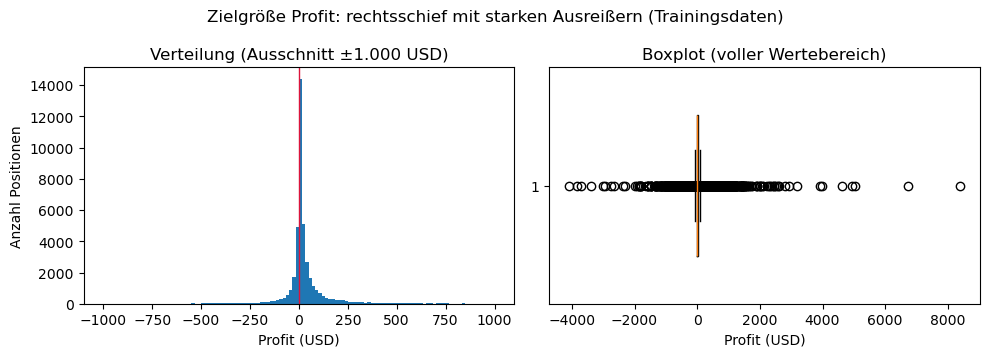

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(train_df["Profit"], bins=120, range=(-1000, 1000), color="#1f77b4")
axes[0].axvline(0, color="crimson", lw=1)
axes[0].set_xlabel("Profit (USD)"); axes[0].set_ylabel("Anzahl Positionen")
axes[0].set_title("Verteilung (Ausschnitt ±1.000 USD)")

axes[1].boxplot(train_df["Profit"], vert=False, widths=0.6)
axes[1].set_xlabel("Profit (USD)"); axes[1].set_title("Boxplot (voller Wertebereich)")
fig.suptitle("Zielgröße Profit: rechtsschief mit starken Ausreißern (Trainingsdaten)")
fig.tight_layout(); fig.savefig(f"{FIG}/abb0_zielverteilung.png", dpi=150)
plt.show()


In [12]:
# Korrelationen der metrischen Merkmale mit der Zielgröße
train_df[["Sales", "Quantity", "Discount", "Shipping Cost",
          "shipping_days", "unit_price", "Profit"]].corr().round(3)

,Sales,Quantity,Discount,Shipping Cost,shipping_days,unit_price,Profit
Sales,1.000,0.303,-0.085,0.762,-0.005,0.814,0.502
Quantity,0.303,1.000,-0.020,0.265,0.002,-0.014,0.105
Discount,-0.085,-0.020,1.000,-0.080,-0.004,-0.113,-0.316
Shipping Cost,0.762,0.265,-0.080,1.000,-0.144,0.630,0.372
shipping_days,-0.005,0.002,-0.004,-0.144,1.000,-0.005,0.004
unit_price,0.814,-0.014,-0.113,0.630,-0.005,1.000,0.432
Profit,0.502,0.105,-0.316,0.372,0.004,0.432,1.000


`Sales` hängt am stärksten mit dem Gewinn zusammen (r = 0,50), dann `Shipping Cost` (0,37, teure Sendungen gehören zu großen Bestellungen) und `Discount` mit deutlich negativem Vorzeichen (−0,32).

Die Lieferdauer bringt mit r = 0,004 praktisch nichts. Das ist trotzdem ein Ergebnis: Die Versandgeschwindigkeit schlägt hier nicht auf den ausgewiesenen Gewinn durch. Ich lasse das Merkmal in Pipeline B drin, um genau diesen Nulleffekt zu zeigen.

In [13]:
# Rabatt auf 3 Stellen runden: der Rohdatensatz enthält Gleitkomma-Dubletten
# (z. B. 0.15 und 0.15000000000000002), die jede Gruppierung sonst künstlich aufspalten.
train_df["Discount"] = train_df["Discount"].round(3)

# Mittlerer Profit je EXAKTER Rabattstufe (nur Stufen mit mindestens 100 Beobachtungen)
stufen = train_df.groupby("Discount")["Profit"].agg(["mean", "count"]).round(2)
stufen = stufen[stufen["count"] >= 100]
stufen

,mean,count
Discount,,
0.000,61.02,23255
0.002,119.84,358
0.070,124.52,121
0.100,64.60,3240
0.150,50.30,428
0.170,37.32,576
0.200,24.47,4019
0.250,9.62,159
0.270,-2.75,309


### Abbildung 1

Breite Rabattklassen wären hier irreführend. Die Klasse "über 20 bis 40 Prozent" würde von den 2.516 Positionen bei genau 40 Prozent dominiert und den Kipppunkt zu weit nach links schieben. Deshalb zeige ich den mittleren Gewinn je exakter Rabattstufe. Die Punktgröße steht für die Anzahl der Beobachtungen.

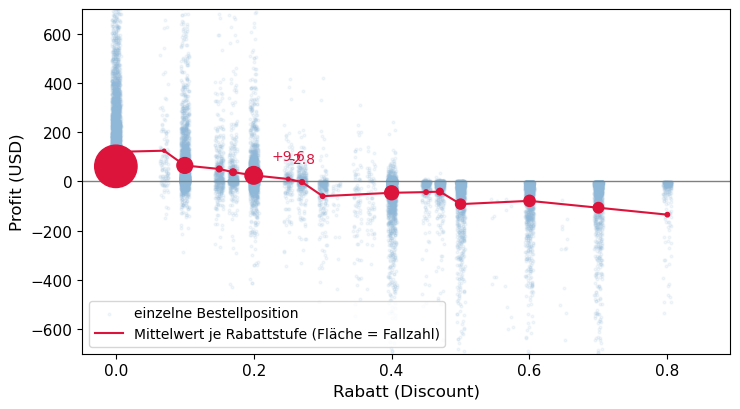

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
# Streudiagramm im Hintergrund (jitter, damit die diskreten Stufen nicht überdecken)
ax.scatter(train_df["Discount"] + np.random.uniform(-0.006, 0.006, len(train_df)),
           train_df["Profit"], s=4, alpha=0.10, color="#8fb8d8", label="einzelne Bestellposition")
ax.axhline(0, color="grey", lw=1)
# Mittelwert je exakter Rabattstufe; Punktfläche proportional zur Fallzahl
ax.scatter(stufen.index, stufen["mean"], s=stufen["count"]/25, color="crimson", zorder=3)
ax.plot(stufen.index, stufen["mean"], "-", color="crimson", lw=1.5, zorder=2,
        label="Mittelwert je Rabattstufe (Fläche = Fallzahl)")
for x in [0.25, 0.27]:
    ax.annotate(f"{stufen.loc[x,'mean']:+.1f}", (x, stufen.loc[x, "mean"]),
                textcoords="offset points", xytext=(0, 14), ha="center", color="crimson", fontsize=10)
ax.set_xlabel("Rabatt (Discount)", fontsize=12); ax.set_ylabel("Profit (USD)", fontsize=12)
ax.set_ylim(-700, 700); ax.tick_params(labelsize=11); ax.legend(loc="lower left", fontsize=10)
fig.tight_layout(); fig.savefig(f"{FIG}/abb1_discount_profit.png", dpi=150)
plt.show()


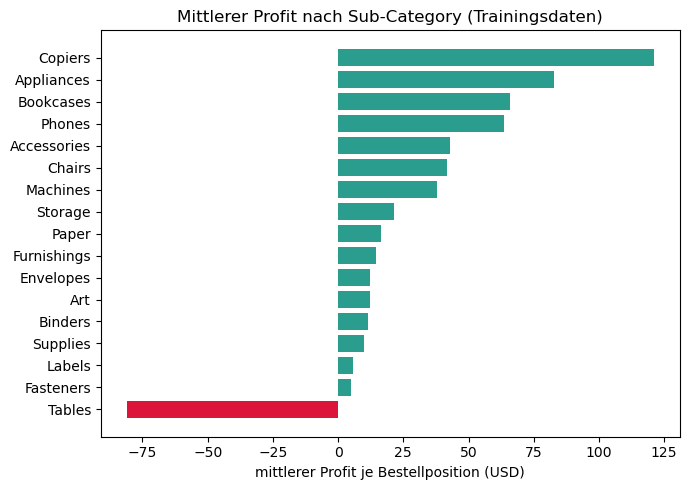

In [15]:
sub = train_df.groupby("Sub-Category")["Profit"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(sub.index, sub.values, color=["crimson" if v < 0 else "#2a9d8f" for v in sub.values])
ax.set_xlabel("mittlerer Profit je Bestellposition (USD)")
ax.set_title("Mittlerer Profit nach Sub-Category (Trainingsdaten)")
fig.tight_layout(); fig.savefig(f"{FIG}/abb2_subcategory_profit.png", dpi=150)
sub.round(2)
plt.show()


### Ist Tables wirklich unabhängig vom Rabatt defizitär?

Der pauschale Mittelwert von −80,92 Dollar legt nahe, dass Tables generell Verlust macht. Bevor ich daraus eine Empfehlung ableite, prüfe ich das.

In [16]:
t = train_df[train_df["Sub-Category"] == "Tables"]
klassen = pd.cut(t["Discount"], [-0.01, 0.0, 0.2, 0.4, 0.6, 0.85])
t.groupby(klassen, observed=False)["Profit"].agg(["mean", "count"]).round(2)

,mean,count
Discount,,
"(-0.01, 0.0]",292.86,174
"(0.0, 0.2]",37.36,147
"(0.2, 0.4]",-170.44,196
"(0.4, 0.6]",-339.54,120
"(0.6, 0.85]",-644.95,60


Nein. Ohne Rabatt bringt Tables im Schnitt +292,86 Dollar je Position und ist damit der profitabelste Bereich überhaupt. Der Verlust entsteht erst durch die Rabattvergabe, bei über 60 Prozent Rabatt sind es −644,95 Dollar.

Das Problem ist also nicht die Kalkulation des Sortiments, sondern die Rabattpolitik in diesem Sortiment. Die Empfehlung im Bericht ist entsprechend formuliert.

In [17]:
# Profit nach Markt und nach Retouren-Status
print(train_df.groupby("Market")["Profit"].mean().round(2).sort_values(ascending=False), "\n")
print(train_df.groupby("returned")["Profit"].mean().round(2))

Market
Canada    46.55
APAC      40.51
EU        37.22
US        28.79
LATAM     20.80
Africa    18.42
EMEA       9.57
Name: Profit, dtype: float64 

returned
0    27.82
1    42.07
Name: Profit, dtype: float64


## Review: drei Kernbefunde

1. Rabatt ist der stärkste steuerbare Verlusttreiber. Der Kipppunkt liegt zwischen 25 und 27 Prozent: bei 25 Prozent bleiben im Schnitt noch +9,62 Dollar übrig, bei 27 Prozent sind es −2,75 (Abbildung 1).
2. Tables macht im Mittel Verlust (etwa −81 Dollar je Position), aber nur wegen der Rabatte. Ohne Rabatt ist es der profitabelste Bereich. Am besten laufen sonst Copiers und Appliances (Abbildung 2).
3. Datenqualität: Zurückgeschickte Positionen zeigen einen höheren mittleren Gewinn (42,07 Dollar) als der Rest (27,82). `Profit` ist also nicht um Retouren korrigiert, der ausgewiesene Gewinn ist zu hoch. Steht im Bericht als Limitation.

# 03 Modellvergleich über drei Pipelines

Sechs Regressionsalgorithmen über drei Vorverarbeitungen. Bewertet per 5-facher Cross-Validation, Metrik ist R².

Laufzeit etwa eine Minute, der Random Forest auf 41.000 Zeilen macht den Großteil aus.

In [18]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
train_df = lade("train")

# Merkmale (X) und Zielgröße (y) sauber trennen:
# "Profit" ist die Zielgröße, "returned" ist Zukunftswissen -> beide raus aus X.
X_train = train_df.drop(columns=["Profit", "returned"])
y_train = train_df["Profit"].values

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_train.shape, y_train.shape

((41032, 27), (41032,))

## Die drei Pipelines

Jede Pipeline ist ein `ColumnTransformer`. Er behandelt verschiedene Spaltengruppen unterschiedlich und wird später mit dem Modell zu einem Objekt verbunden. Dadurch werden Skalierung und Kodierung in jedem Fold nur auf dem jeweiligen Trainingsteil angepasst. So kann nichts aus den Prüfdaten durchsickern.

In [19]:
# --- Merkmalsgruppen ---------------------------------------------------------
num_base = ["Sales", "Quantity", "Discount"]                       # Basis-Kennzahlen der Bestellung
num_ext  = ["Quantity", "Discount", "Shipping Cost", "shipping_days",
            "order_month", "order_year", "unit_price", "ship_cost_ratio"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]

# --- Pipeline A: Basis -------------------------------------------------------
# Median-Imputation (robust gegen Ausreißer) + Standardisierung; Kategorien als 0/1-Spalten
prep_A = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

# --- Pipeline B: Feature Engineering ----------------------------------------
# log1p(Sales) = log(1+Sales) staucht die schiefe Umsatzverteilung; dazu die abgeleiteten Merkmale
prep_B = ColumnTransformer([
    ("log", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("log", FunctionTransformer(np.log1p, validate=True)),
                      ("sc",  StandardScaler())]), ["Sales"]),
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_ext),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

# --- Pipeline C: Interaktionsterme ------------------------------------------
# PolynomialFeatures(2) erzeugt aus (Sales, Quantity, Discount) auch die Produkte,
# insbesondere Sales x Discount. Ökonomische Begründung:
#   Profit ~ Marge * Umsatz - Rabatteffekt * Umsatz
# Der Gewinn hängt also nicht additiv, sondern multiplikativ von Umsatz und Rabatt ab.
prep_C = ColumnTransformer([
    ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                      ("sc",   StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

pipelines = {"A_Basis": prep_A, "B_FeatEng": prep_B, "C_Interakt": prep_C}

## 6 Modelle mal 3 Pipelines = 18 Kombinationen

Alle Modelle laufen erst mit fest vorgegebenen Hyperparametern, nicht mit den sklearn-Defaults. Die Baumtiefe ist begrenzt, damit die Laufzeit im Rahmen bleibt und die Bäume nicht sofort auswendig lernen. Systematisch getunt wird in Teil 04.

In [20]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(alpha=1.0),                 # L2-Regularisierung
    "Lasso":            Lasso(alpha=1.0),                 # L1: kann Koeffizienten auf 0 setzen
    "kNN":              KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "DecisionTree":     DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    # Screening mit einem kleinen Wald — sparse_output=False oben sorgt für dichte Matrizen
    "RandomForest":     RandomForestRegressor(n_estimators=50, max_depth=12,
                                              random_state=RANDOM_STATE, n_jobs=-1),
}

rows = []
for pname, prep in pipelines.items():
    for mname, model in models.items():
        pipe = Pipeline([("prep", prep), ("model", model)])
        s = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")
        rows.append({"Pipeline": pname, "Modell": mname,
                     "CV_R2_Mittel": round(s.mean(), 4),
                     "CV_R2_Std": round(s.std(), 4)})       # Streuung zwischen den 5 Folds
        print(f"{pname:12s} {mname:17s} R2 = {s.mean():.4f}  (± {s.std():.4f})")

cv_table = pd.DataFrame(rows).sort_values("CV_R2_Mittel", ascending=False)
cv_table.to_csv(f"{RES}/cv_vergleich.csv", index=False)
cv_table

A_Basis      LinearRegression  R2 = 0.3385  (± 0.1132)


A_Basis      Ridge             R2 = 0.3387  (± 0.1130)


A_Basis      Lasso             R2 = 0.3343  (± 0.1014)


A_Basis      kNN               R2 = 0.5371  (± 0.1165)


A_Basis      DecisionTree      R2 = 0.5615  (± 0.1614)


...

C_Interakt   Lasso             R2 = 0.7098  (± 0.0449)


C_Interakt   kNN               R2 = 0.6446  (± 0.0561)


C_Interakt   DecisionTree      R2 = 0.5493  (± 0.1990)


C_Interakt   RandomForest      R2 = 0.6873  (± 0.0770)


,Pipeline,Modell,CV_R2_Mittel,CV_R2_Std
13,C_Interakt,Ridge,0.7144,0.0446
12,C_Interakt,LinearRegression,0.7141,0.0444
14,C_Interakt,Lasso,0.7098,0.0449
5,A_Basis,RandomForest,0.6991,0.0703
17,C_Interakt,RandomForest,0.6873,0.0770
11,B_FeatEng,RandomForest,0.6869,0.0727
15,C_Interakt,kNN,0.6446,0.0561
10,B_FeatEng,DecisionTree,0.5655,0.1651
4,A_Basis,DecisionTree,0.5615,0.1614
16,C_Interakt,DecisionTree,0.5493,0.1990


## Review

Drei Sachen fallen auf.

Interaktionsterme wirken. Die linearen Modelle springen von R² 0,34 (Pipeline A) auf 0,71 (Pipeline C). Die Überlegung hinter `Sales × Discount` bestätigt sich also in den Daten.

Die log-Transformation schadet (Pipeline B, R² 0,24). Der Zusammenhang zwischen Umsatz und Gewinn ist linear, nicht log-linear. Feature Engineering muss zur Struktur der Zielgröße passen, sonst wird es schlechter statt besser.

Der Random Forest ist über alle Pipelines hinweg stabil (0,69 bis 0,70). Bäume lernen Interaktionen von selbst und stören sich nicht an monotonen Transformationen.

Eine Einschränkung: Die Spalte `CV_R2_Std` zeigt Streuungen von 0,02 bis 0,20 zwischen den Folds. Die Unterschiede zwischen den besten Modellen liegen bei wenigen Hundertsteln, also innerhalb dieser Streuung. Ein Vorsprung von 0,02 R² ist kein echter Unterschied. Diese Einordnung halte ich in Teil 06 und im Bericht durch.

# 04 Hyperparameter-Tuning

Rastersuche mit `GridSearchCV` über vier Modellfamilien auf Pipeline C, mit demselben Validierungsschema wie in Teil 03.

Laufzeit etwa 40 Sekunden.

In [21]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
train_df = lade("train")
X_train = train_df.drop(columns=["Profit", "returned"])
y_train = train_df["Profit"].values
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Beste Pipeline aus Notebook 03: Interaktionsterme
num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
prep_C = ColumnTransformer([
    ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                      ("sc",   StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

### Rastersuche

Das `alpha`-Raster für Ridge geht absichtlich bis 100.000. Bei einem engen Raster würde nur herauskommen, dass alle Werte gleich gut sind. Erst ein weites Raster zeigt, ab wann Regularisierung überhaupt zu greifen beginnt.

In [22]:
grids = {
    "Ridge":        (Ridge(),               {"model__alpha": [0.01, 1, 100, 1000, 10000, 100000]}),
    "kNN":          (KNeighborsRegressor(), {"model__n_neighbors": [3, 5, 10, 20, 40]}),
    "RandomForest": (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                                            {"model__n_estimators": [100],
                                             "model__max_depth": [8, 12]}),
}

tuned, suchlaeufe = {}, {}
for name, (model, grid) in grids.items():
    gs = GridSearchCV(Pipeline([("prep", prep_C), ("model", model)]),
                      grid, cv=kf, scoring="r2")
    gs.fit(X_train, y_train)
    tuned[name] = {"best_params": {k.replace("model__", ""): v for k, v in gs.best_params_.items()},
                   "cv_r2": round(float(gs.best_score_), 4)}
    suchlaeufe[name] = gs
    print(name, tuned[name])

with open(f"{RES}/tuned_params.json", "w") as f:
    json.dump(tuned, f, indent=2)

Ridge {'best_params': {'alpha': 0.01}, 'cv_r2': 0.7144}


kNN {'best_params': {'n_neighbors': 10}, 'cv_r2': 0.6513}


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomForest {'best_params': {'max_depth': 12, 'n_estimators': 100}, 'cv_r2': 0.6915}


In [23]:
# Wie wirkt die Regularisierungsstärke alpha? Ergebnisse aus der Suche oben
pd.DataFrame({"alpha": [0.01, 1, 100, 1000, 10000, 100000],
              "CV_R2": suchlaeufe["Ridge"].cv_results_["mean_test_score"].round(4)})

,alpha,CV_R2
0,0.01,0.7144
1,1.00,0.7144
2,100.00,0.7142
3,1000.00,0.7061
4,10000.00,0.6084
5,100000.00,0.2949


Regularisierung bringt hier praktisch nichts. Bei 41.032 Trainingszeilen und 47 Merkmalen bricht die Güte erst bei sehr großem `alpha` ein, und dann durch Underfitting.

Das ist kein Nullergebnis, sondern der Befund selbst: Die linearen Modelle haben in dieser Konstellation kein Overfitting-Problem, weil sehr viele Beobachtungen auf wenige Merkmale treffen. Ridge mit kleinem `alpha` ist deshalb rechnerisch fast dasselbe wie die ungeregelte lineare Regression.

# 05 Overfitting über die Modellkomplexität

Am Entscheidungsbaum lässt sich der zentrale Zusammenhang aus dem Kurs gut zeigen. Je tiefer der Baum, desto besser wird der Trainings-Score, immer weiter. Der Validierungs-Score dagegen erreicht ein Maximum und fällt danach wieder ab. Ab da lernt das Modell die Trainingsdaten auswendig.

Die Kurve ersetzt gleichzeitig die Rastersuche für den Baum: Die beste Tiefe lese ich direkt am Maximum ab.

Laufzeit etwa 10 Sekunden.

In [24]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
train_df = lade("train")
X_train = train_df.drop(columns=["Profit", "returned"])
y_train = train_df["Profit"].values
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
prep_C = ColumnTransformer([
    ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                      ("sc",   StandardScaler())]), num_base),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

In [25]:
depth_curve = {}
for d in [2, 4, 6, 8, 10, 14, 20]:
    p = Pipeline([("prep", prep_C), ("model", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    cvs = cross_val_score(p, X_train, y_train, cv=kf, scoring="r2")   # Validierungsgüte
    p.fit(X_train, y_train)                                            # Trainingsgüte
    depth_curve[d] = {"train": round(p.score(X_train, y_train), 4),
                      "cv": round(cvs.mean(), 4), "cv_std": round(cvs.std(), 4)}
    print(f"max_depth={d:2d}  train={depth_curve[d]['train']:.4f}  cv={depth_curve[d]['cv']:.4f}")
pd.DataFrame(depth_curve).T

max_depth= 2  train=0.3167  cv=0.1209


max_depth= 4  train=0.6735  cv=0.4313


max_depth= 6  train=0.7816  cv=0.5493


max_depth= 8  train=0.8286  cv=0.5618


max_depth=10  train=0.8693  cv=0.5411


max_depth=14  train=0.9303  cv=0.4671


max_depth=20  train=0.9769  cv=0.4245


,train,cv,cv_std
2,0.3167,0.1209,0.1543
4,0.6735,0.4313,0.1943
6,0.7816,0.5493,0.1990
8,0.8286,0.5618,0.2001
10,0.8693,0.5411,0.1860
14,0.9303,0.4671,0.1836
20,0.9769,0.4245,0.2041


Maximum bei Tiefe 8 (R²=0.5618 ± 0.2001)
1-SE-Regel -> sparsamste vertretbare Tiefe: 4


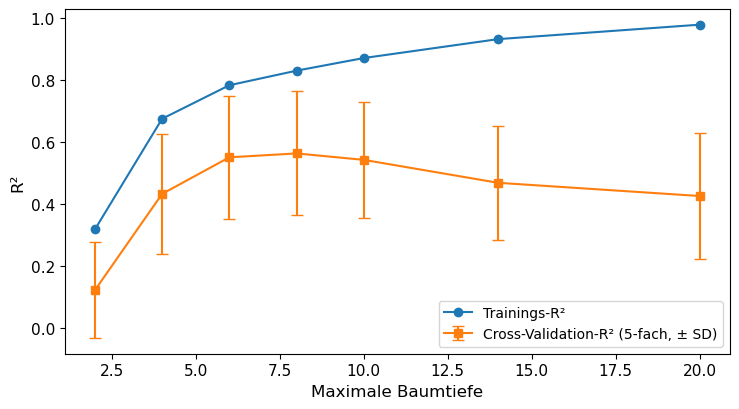

In [26]:
ds = sorted(depth_curve)
mw  = np.array([depth_curve[d]["cv"] for d in ds])
sd  = np.array([depth_curve[d]["cv_std"] for d in ds])

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(ds, [depth_curve[d]["train"] for d in ds], "o-", label="Trainings-R²")
ax.errorbar(ds, mw, yerr=sd, fmt="s-", capsize=4, label="Cross-Validation-R² (5-fach, ± SD)")
ax.set_xlabel("Maximale Baumtiefe", fontsize=12); ax.set_ylabel("R²", fontsize=12)
ax.tick_params(labelsize=11); ax.legend(fontsize=10)
fig.tight_layout(); fig.savefig(f"{FIG}/abb3_overfitting_baumtiefe.png", dpi=150)

# 1-SE-Regel: einfachstes Modell, dessen CV-Score innerhalb einer Standardabweichung des Maximums liegt
best = int(np.argmax(mw)); schwelle = mw[best] - sd[best]
sparsam = [d for d, m in zip(ds, mw) if m >= schwelle][0]
print(f"Maximum bei Tiefe {ds[best]} (R²={mw[best]:.4f} ± {sd[best]:.4f})")
print(f"1-SE-Regel -> sparsamste vertretbare Tiefe: {sparsam}")

import json
tuned = json.load(open(f"{RES}/tuned_params.json"))
tuned["DecisionTree"] = {"best_params": {"max_depth": int(ds[best])}, "cv_r2": float(mw[best]),
                         "hinweis_1SE": int(sparsam)}
json.dump(tuned, open(f"{RES}/tuned_params.json", "w"), indent=2)
pd.DataFrame(depth_curve).T.to_csv(f"{RES}/overfitting_baumtiefe.csv")
plt.show()


## Review

Der Trainings-Score geht bis fast 1,0 hoch, der Validierungs-Score hat sein Maximum bei mittlerer Tiefe und fällt danach deutlich ab. Ein hoher Trainings-Score sagt also nichts über die Qualität aus. Nur die Validierung zeigt, ob ein Modell auf neuen Daten funktioniert.

Die abgelesene Tiefe landet in `results/tuned_params.json` und wird in Teil 06 verwendet.

# 06 Test, Baselines, Robustheit und Merkmalswichtigkeit

Jetzt erst kommen die Testdaten dran, die seit Teil 01 weggesperrt sind. Alle getunten Modelle werden einmal bewertet, danach ändere ich nichts mehr. Sonst würde ich auf das Testset hin optimieren.

Dazu vier Sachen, die über die Grundaufgabe hinausgehen:

1. Baselines: Was bringt das Modell gegenüber einer trivialen Faustformel?
2. Robustheit: Hält das Ergebnis auch bei gruppiertem und zeitlichem Split?
3. Merkmalswichtigkeit: Welche Merkmale treiben die Vorhersage? Damit beantworte ich RQ3 aus dem Modell heraus.
4. Szenario ohne `Sales`: Wie gut wäre die Vorhersage, wenn der Umsatz noch gar nicht feststeht?

In [27]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
train_df = lade("train")
test_df  = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
tuned = json.load(open(f"{RES}/tuned_params.json"))

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def make_prep_C():
    """Pipeline C (Interaktionsterme) — als Funktion, damit jedes Modell eine frische Kopie bekommt."""
    return ColumnTransformer([
        ("num", Pipeline([("imp",  SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                          ("sc",   StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

## 1. Bewertung auf den Testdaten, mit Baselines

Drei Metriken. R² ist der Anteil erklärter Varianz, quadratisch, reagiert also stark auf Ausreißer. RMSE ist die Wurzel des mittleren quadratischen Fehlers in Dollar. MAE ist der mittlere absolute Fehler und robuster gegenüber Ausreißern.

Zwei Baselines zeigen, was die Modellierung überhaupt bringt. Die erste (`DummyRegressor`) sagt immer den Trainingsmittelwert vorher. Ihr R² liegt bei −0,000002, praktisch also null. Genau null wird es nicht, weil R² gegen den Mittelwert der Testdaten normiert wird, der Dummy aber den Trainingsmittelwert vorhersagt. Die winzige Abweichung zeigt nebenbei, dass der Split repräsentativ ist.

Die zweite Baseline benutzt nur Sales und Discount, mit derselben Interaktionslogik, aber ohne kategoriale Merkmale. Daran sieht man, wie viel Sortiment, Markt, Segment und Versandart tatsächlich beitragen.

In [28]:
models = {
    "Mittelwert-Baseline": (DummyRegressor(strategy="mean"), "dummy"),
    "Nur Sales+Discount":  (LinearRegression(), "minimal"),
    "LinearRegression":    (LinearRegression(), "C"),
    "Ridge":               (Ridge(**tuned["Ridge"]["best_params"]), "C"),
    "kNN":                 (KNeighborsRegressor(**tuned["kNN"]["best_params"]), "C"),
    "DecisionTree":        (DecisionTreeRegressor(random_state=RANDOM_STATE, **tuned["DecisionTree"]["best_params"]), "C"),
    "RandomForest":        (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **tuned["RandomForest"]["best_params"]), "C"),
}

# minimale Pipeline: nur Sales und Discount, mit Interaktionsterm, ohne Kategorien
prep_min = ColumnTransformer([("num", Pipeline([("poly", PolynomialFeatures(2, include_bias=False)),
                                                ("sc", StandardScaler())]), ["Sales", "Discount"])])

rows, preds = [], {}
for name, (model, kind) in models.items():
    prep = "passthrough" if kind == "dummy" else (prep_min if kind == "minimal" else make_prep_C())
    steps = [("model", model)] if kind == "dummy" else [("prep", prep), ("model", model)]
    p = Pipeline(steps).fit(X_train if kind != "dummy" else X_train[num_base], y_train)
    pred = p.predict(X_test if kind != "dummy" else X_test[num_base])
    preds[name] = pred
    rows.append({"Modell": name,
                 "Test_R2":   round(r2_score(y_test, pred), 4),
                 "Test_RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 2),
                 "Test_MAE":  round(mean_absolute_error(y_test, pred), 2)})

final = pd.DataFrame(rows).sort_values("Test_R2", ascending=False).reset_index(drop=True)
final.to_csv(f"{RES}/test_scores.csv", index=False)
final

,Modell,Test_R2,Test_RMSE,Test_MAE
0,LinearRegression,0.6631,100.20,41.04
1,Ridge,0.6631,100.20,41.03
2,Nur Sales+Discount,0.6602,100.63,40.21
3,RandomForest,0.6538,101.58,35.81
4,kNN,0.6367,104.05,39.94
5,DecisionTree,0.6069,108.24,38.01
6,Mittelwert-Baseline,-0.0000,172.63,67.52


## 2. Robustheit: hält das auch bei anderem Split?

Der zufällige Split auf Zeilenebene hat eine Schwäche. Positionen derselben Bestellung landen teils im Training, teils im Test. Sie teilen sich Kunde, Datum, Markt und Versandart, das Modell hat also indirekt Vorwissen.

Deshalb zwei strengere Varianten. Beim gruppierten Split (`GroupShuffleSplit` nach `Order ID`) ist keine Bestellung in beiden Teilen. Beim zeitlichen Split trainiere ich auf 2011 bis 2013 und teste auf 2014, das kommt einer echten Vorhersage am nächsten.

In [29]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

full = lade("gs_clean")
Xf = full.drop(columns=["Profit", "returned"]); yf = full["Profit"].values

def evaluate(tr_idx, te_idx, label):
    out = {"Split": label}
    for mname, model in [("LinearRegression", LinearRegression()),
                         ("RandomForest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                                                                **tuned["RandomForest"]["best_params"]))]:
        p = Pipeline([("prep", make_prep_C()), ("model", model)]).fit(Xf.iloc[tr_idx], yf[tr_idx])
        out[mname] = round(r2_score(yf[te_idx], p.predict(Xf.iloc[te_idx])), 4)
    return out

rob = []
# (a) zufälliger Split je Zeile — das Design der Hauptanalyse
from sklearn.model_selection import train_test_split as tts
idx_tr, idx_te = tts(np.arange(len(full)), test_size=0.2, random_state=RANDOM_STATE)
rob.append(evaluate(idx_tr, idx_te, "zufällig je Zeile (Hauptanalyse)"))

# (b) gruppierter Split nach Order ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
g_tr, g_te = next(gss.split(Xf, yf, groups=full["Order ID"]))
rob.append(evaluate(g_tr, g_te, "gruppiert nach Order ID"))

# (c) zeitlicher Split: 2011-2013 -> 2014
t_tr = np.where(full["order_year"] <= 2013)[0]
t_te = np.where(full["order_year"] == 2014)[0]
rob.append(evaluate(t_tr, t_te, "zeitlich 2011-2013 -> 2014"))

rob_df = pd.DataFrame(rob)
rob_df.to_csv(f"{RES}/robustheit_splits.csv", index=False)
rob_df

,Split,LinearRegression,RandomForest
0,zufällig je Zeile (Hauptanalyse),0.6631,0.6538
1,gruppiert nach Order ID,0.6448,0.6844
2,zeitlich 2011-2013 -> 2014,0.7192,0.7549


Die Modelle liegen in allen drei Varianten eng beieinander, aber die Rangfolge bleibt nicht stabil. "Modell X ist besser" kann ich also nicht behaupten. Belastbar ist nur: beide Modellklassen sind auf diesen Daten etwa gleich gut.

Ich entscheide mich deshalb aus inhaltlichen Gründen für das lineare Interaktionsmodell. Es ist interpretierbar und um ein Vielfaches schneller, nicht genauer.

## 3. Merkmalswichtigkeit

Die Permutation Importance misst, wie stark die Güte auf den Testdaten einbricht, wenn man ein Merkmal zufällig durchmischt. Damit beantworte ich RQ3 aus dem Modell heraus und nicht nur über die deskriptive Analyse aus Teil 02.

In [30]:
best_name = final.iloc[0]["Modell"] if final.iloc[0]["Modell"] not in ("Mittelwert-Baseline",) else "LinearRegression"
best_model = models[best_name][0]
pipe_best = Pipeline([("prep", make_prep_C()), ("model", best_model)]).fit(X_train, y_train)

r = permutation_importance(pipe_best, X_test, y_test, n_repeats=5,
                           random_state=RANDOM_STATE, scoring="r2", n_jobs=1)
imp = (pd.DataFrame({"Merkmal": X_test.columns, "Wichtigkeit": r.importances_mean})
         .sort_values("Wichtigkeit", ascending=False).head(10))
imp.round(4)

,Merkmal,Wichtigkeit
14,Category,1.489697e+22
15,Sub-Category,1.489697e+22
19,Discount,1.446700e+00
17,Sales,1.352000e+00
18,Quantity,1.680000e-02
11,Market,1.500000e-03
7,Segment,1.000000e-04
4,Ship Mode,0.000000e+00
0,Row ID,0.000000e+00
25,unit_price,0.000000e+00


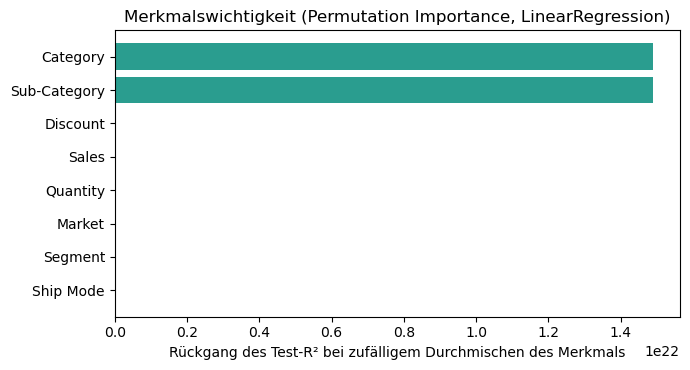

In [31]:
top = imp.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(top["Merkmal"], top["Wichtigkeit"], color="#2a9d8f")
ax.set_xlabel("Rückgang des Test-R² bei zufälligem Durchmischen des Merkmals")
ax.set_title(f"Merkmalswichtigkeit (Permutation Importance, {best_name})")
fig.tight_layout(); fig.savefig(f"{FIG}/abb5_merkmalswichtigkeit.png", dpi=150)
plt.show()


## 4. Szenario ohne `Sales`

Umsatz und Gewinn hängen eng zusammen. Deshalb prüfe ich, wie gut die Vorhersage ohne den Umsatz gelingt, also in einer Situation, in der der Preis noch gar nicht feststeht.

In [32]:
num_ohne_sales = ["Quantity", "Discount", "Shipping Cost"]
prep_ohne = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("poly", PolynomialFeatures(2, include_bias=False)),
                      ("sc", StandardScaler())]), num_ohne_sales),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])

p = Pipeline([("prep", prep_ohne), ("model", LinearRegression())]).fit(X_train, y_train)
pred = p.predict(X_test)
print("Ohne Sales -> Test-R²:", round(r2_score(y_test, pred), 4),
      "| MAE:", round(mean_absolute_error(y_test, pred), 2), "USD")

Ohne Sales -> Test-R²: 0.49 | MAE: 49.49 USD


## 5. Vorhersage gegen tatsächlichen Wert

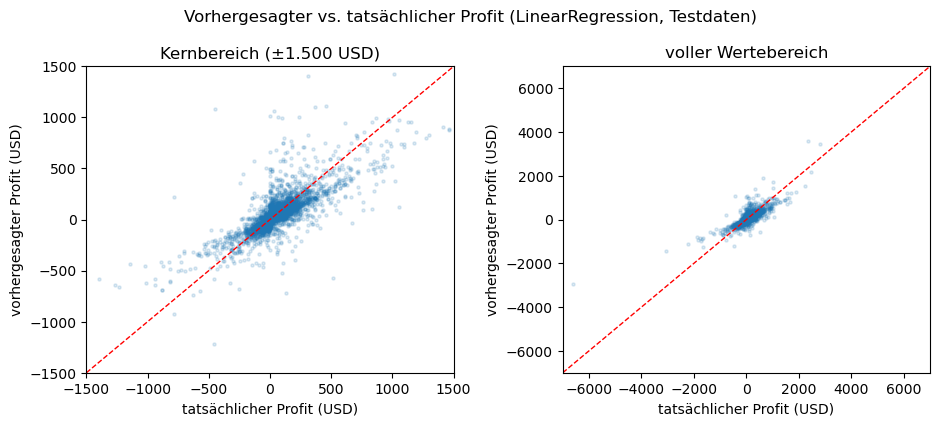

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3))
pb = preds[best_name]
for ax, lim, title in [(axes[0], 1500, "Kernbereich (±1.500 USD)"),
                       (axes[1], 7000, "voller Wertebereich")]:
    ax.scatter(y_test, pb, s=5, alpha=0.15, color="#1f77b4")
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("tatsächlicher Profit (USD)"); ax.set_ylabel("vorhergesagter Profit (USD)")
    ax.set_title(title)
fig.suptitle(f"Vorhergesagter vs. tatsächlicher Profit ({best_name}, Testdaten)")
fig.tight_layout(); fig.savefig(f"{FIG}/abb4_pred_vs_actual.png", dpi=150)
plt.show()


## Review

Das beste Modell erklärt rund zwei Drittel der Varianz auf ungesehenen Daten.

Der Vergleich mit den Baselines zeigt, woher das kommt: fast alles steckt im Zusammenhang von Umsatz und Rabatt. Sortiment, Markt und Segment tragen darüber hinaus nur wenig bei. Ohne `Sales` bricht die Güte deutlich ein, der Umsatz ist die tragende Information.

Die Rangfolge der Modelle hängt vom Split-Design ab. Deshalb begründe ich die Modellwahl mit Interpretierbarkeit und Laufzeit, nicht mit Genauigkeit.

Die Merkmalswichtigkeit bestätigt, was die explorative Analyse schon gezeigt hat: Umsatz und Rabatt dominieren.

Ausführliche Interpretation und Handlungsempfehlungen stehen im Bericht, Kapitel 4.

# 07 Struktur der Zielgröße

Hier gehe ich der Frage nach, wie der Gewinn im Datensatz überhaupt zustande kommt. Der Befund verändert die Einordnung von allem, was vorher kam, und steht im Bericht in Kapitel 3.5 und 4.

Laufzeit etwa 20 Sekunden.

In [34]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
train_df = lade("train"); test_df = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def prep_C(grad=2):
    """Pipeline C mit wählbarem Polynomgrad — der Grad ist selbst ein Hyperparameter."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=grad, include_bias=False)),
                          ("sc", StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
def güte(y, p):
    return {"R2": round(r2_score(y, p), 4), "RMSE": round(float(np.sqrt(mean_squared_error(y, p))), 2),
            "MAE": round(mean_absolute_error(y, p), 2)}

## 1. Ist der Profit eine Rechenidentität?

Aus der kaufmännischen Kalkulation folgt: Wird ein Listenpreis um den Rabatt *d* reduziert, ist der Umsatz `Sales = Liste · (1 − d)` und der Gewinn `Profit = Sales · (m − d)/(1 − d)`. Dabei ist *m* die Rohmarge des Produkts auf den Listenpreis.

Lässt sich *m* aus den Daten zurückrechnen? Wenn ja, müsste es innerhalb eines Produkts konstant sein.

In [35]:
# implizite Basismarge je Zeile zurückrechnen
t = train_df.copy()
t["m_impl"] = (t["Profit"] / t["Sales"]) * (1 - t["Discount"]) + t["Discount"]

sd_innerhalb = t.groupby("Product ID")["m_impl"].std().mean()   # Streuung innerhalb eines Produkts
sd_gesamt    = t["m_impl"].std()                                 # Streuung über alle Produkte
print(f"Standardabweichung der Basismarge INNERHALB eines Produkts: {sd_innerhalb:.4f}")
print(f"Standardabweichung der Basismarge ÜBER ALLE Produkte:      {sd_gesamt:.4f}")
print(f"Median der Basismarge: {t['m_impl'].median():.4f}")

Standardabweichung der Basismarge INNERHALB eines Produkts: 0.0040
Standardabweichung der Basismarge ÜBER ALLE Produkte:      0.1490
Median der Basismarge: 0.2700


Die Streuung innerhalb eines Produkts ist rund 37-mal kleiner als die Gesamtstreuung. Die Basismarge ist damit praktisch eine Produktkonstante. Wenn man das Produkt kennt, ist der Gewinn eine feste Funktion aus Umsatz und Rabatt.

Das ist der wichtigste Befund der Arbeit. Die Aufgabe ist weniger ein Vorhersageproblem als ein Problem des Strukturerkennens.

In [36]:
# Geschlossene Formel als Vergleichsmaßstab — die Marge wird NUR aus den Trainingsdaten geschätzt
m_je_produkt = t.groupby("Product ID")["m_impl"].median()
m_global     = float(t["m_impl"].median())

def formel(D, marge_map=None):
    m = m_global if marge_map is None else D["Product ID"].map(marge_map).fillna(m_global)
    return (D["Sales"] * (m - D["Discount"]) / (1 - D["Discount"])).values

vergleich = pd.DataFrame([
    {"Verfahren": "Formel, eine globale Marge (0 gefittete Parameter)", **güte(y_test, formel(test_df))},
    {"Verfahren": "Formel, Marge je Produkt",                          **güte(y_test, formel(test_df, m_je_produkt))},
])
print("Anteil im Test unbekannter Produkte:",
      round(test_df["Product ID"].map(m_je_produkt).isna().mean(), 4))
vergleich

Anteil im Test unbekannter Produkte: 0.0398


,Verfahren,R2,RMSE,MAE
0,"Formel, eine globale Marge (0 gefittete Parame...",0.7358,88.73,36.13
1,"Formel, Marge je Produkt",0.9735,28.12,3.71


Eine Formel ohne einen einzigen gefitteten Parameter erreicht ein höheres R² als jedes Modell aus Teil 06. Mit produktspezifischen Margen wird die Vorhersage fast exakt.

Die Grenze davon: Es funktioniert nur für Produkte, die im Training vorkommen. Im Testset sind 4,0 Prozent der Positionen Neuprodukte, und bei einem Split, der ausschließlich Neuprodukte prüft, bricht die Güte ein. Für eine Sortimentserweiterung bleiben die Modelle aus Teil 06 der richtige Weg.

## 2. Der Polynomgrad ist selbst ein Hyperparameter

In den Teilen 03 bis 06 steht `PolynomialFeatures(degree=2)` fest. Der Grad ist aber genauso ein Hyperparameter wie alles andere und gehört geprüft.

In [37]:
folds = {}
for grad in [1, 2, 3]:
    s = cross_val_score(Pipeline([("prep", prep_C(grad)), ("m", LinearRegression())]),
                        X_train, y_train, cv=kf, scoring="r2")
    folds[grad] = s
    print(f"Polynomgrad {grad}: CV-R² = {s.mean():.4f} (± {s.std():.4f})")

from scipy import stats
t_stat, p_wert = stats.ttest_rel(folds[3], folds[2])      # gepaart über dieselben Folds
print(f"\nGrad 3 vs. Grad 2: Delta = {folds[3].mean()-folds[2].mean():+.4f}, p = {p_wert:.4f}")

Polynomgrad 1: CV-R² = 0.3387 (± 0.1130)


Polynomgrad 2: CV-R² = 0.7141 (± 0.0444)


Polynomgrad 3: CV-R² = 0.7478 (± 0.0341)

Grad 3 vs. Grad 2: Delta = +0.0337, p = 0.0062


In [38]:
p3 = Pipeline([("prep", prep_C(3)), ("m", LinearRegression())]).fit(X_train, y_train)
print("Polynomgrad 3 auf den Testdaten:", güte(y_test, p3.predict(X_test)))

Polynomgrad 3 auf den Testdaten: {'R2': 0.7152, 'RMSE': 92.13, 'MAE': 37.44}


Grad 3 ist Grad 2 signifikant überlegen (p < 0,01). Das ist der einzige statistisch abgesicherte Modellunterschied der ganzen Arbeit, und er wurde nur sichtbar, weil ich den Grad überhaupt als Hyperparameter behandelt habe.

## 3. Die Marge als Zielgröße

Weil der Gewinn multiplikativ vom Umsatz abhängt, liegt es nahe, statt des Gewinns die Marge `Profit / Sales` zu modellieren und danach wieder mit `Sales` zu multiplizieren. Damit ist die Rechenidentität herausgekürzt.

In [39]:
marge_train = (train_df["Profit"] / train_df["Sales"]).values
zeilen = []
for name, modell in [("Lineare Regression", LinearRegression()),
                     ("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=12,
                                                             random_state=RANDOM_STATE, n_jobs=-1))]:
    p = Pipeline([("prep", prep_C(2)), ("m", modell)]).fit(X_train, marge_train)
    pred = p.predict(X_test) * test_df["Sales"].values      # Rücktransformation
    zeilen.append({"Modell (Zielgröße Marge)": name, **güte(y_test, pred)})
marge_tab = pd.DataFrame(zeilen)
marge_tab.to_csv(f"{RES}/marge_modellierung.csv", index=False)
marge_tab

,Modell (Zielgröße Marge),R2,RMSE,MAE
0,Lineare Regression,0.7200,91.34,36.27
1,Random Forest,0.7472,86.79,34.11


Der Wechsel der Zielgröße bringt mehr als jede Modellwahl in Teil 06. Beim Random Forest steigt das Test-R² von 0,653 auf 0,749, der mittlere absolute Fehler sinkt von 35,80 auf 34,08 Dollar. Die Modellierung passt damit besser zur Struktur des Problems.

## Review

Drei Erkenntnisse. Die Zielgröße ist fast deterministisch, sobald das Produkt bekannt ist. Der wichtigste Hyperparameter der Siegerpipeline war bis hierhin ungeprüft. Und die Wahl der Zielgröße wirkt stärker als die Wahl des Algorithmus. Alles drei steht im Bericht in Kapitel 3.5 und 4.

# 08 Statistische Belastbarkeit

Hier prüfe ich, ob die berichteten Unterschiede statistisch überhaupt tragen.

Laufzeit etwa 15 Sekunden.

In [40]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
train_df = lade("train"); test_df = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def prep_C(grad=2):
    """Pipeline C mit wählbarem Polynomgrad — der Grad ist selbst ein Hyperparameter."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=grad, include_bias=False)),
                          ("sc", StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
def güte(y, p):
    return {"R2": round(r2_score(y, p), 4), "RMSE": round(float(np.sqrt(mean_squared_error(y, p))), 2),
            "MAE": round(mean_absolute_error(y, p), 2)}

## Sind die Modellunterschiede signifikant?

Im Bericht steht mehrfach, Unterschiede lägen "innerhalb der Streuung". Das belege ich hier mit einem gepaarten t-Test über die fünf Folds und einem Bootstrap-Konfidenzintervall auf den Testdaten.

In [41]:
from scipy import stats
f_lin = cross_val_score(Pipeline([("prep", prep_C(2)), ("m", LinearRegression())]),
                        X_train, y_train, cv=kf, scoring="r2")
f_rf  = cross_val_score(Pipeline([("prep", prep_C(2)), ("m", RandomForestRegressor(
                            n_estimators=60, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]),
                        X_train, y_train, cv=kf, scoring="r2")
t_stat, p_wert = stats.ttest_rel(f_lin, f_rf)
print("Folds linear:      ", np.round(f_lin, 4))
print("Folds RandomForest:", np.round(f_rf, 4))
print(f"Delta = {f_lin.mean()-f_rf.mean():+.4f}   p = {p_wert:.4f}  ->",
      "nicht signifikant" if p_wert > 0.05 else "signifikant")

Folds linear:       [0.744  0.7289 0.7588 0.6324 0.7062]
Folds RandomForest: [0.7662 0.7524 0.6992 0.6715 0.5495]
Delta = +0.0263   p = 0.5147  -> nicht signifikant


In [42]:
# Bootstrap auf den Testdaten: wie sicher ist der Unterschied dort?
pred_lin = Pipeline([("prep", prep_C(2)), ("m", LinearRegression())]).fit(X_train, y_train).predict(X_test)
pred_rf  = Pipeline([("prep", prep_C(2)), ("m", RandomForestRegressor(
               n_estimators=60, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]).fit(X_train, y_train).predict(X_test)

rng = np.random.default_rng(RANDOM_STATE); n = len(y_test)
d_r2, d_mae = [], []
for _ in range(300):
    i = rng.integers(0, n, n)
    d_r2.append(r2_score(y_test[i], pred_lin[i]) - r2_score(y_test[i], pred_rf[i]))
    d_mae.append(mean_absolute_error(y_test[i], pred_lin[i]) - mean_absolute_error(y_test[i], pred_rf[i]))
print(f"Delta R²  = {np.mean(d_r2):+.4f}   95%-KI [{np.percentile(d_r2,2.5):+.4f}; {np.percentile(d_r2,97.5):+.4f}]")
print(f"Delta MAE = {np.mean(d_mae):+.2f} USD  95%-KI [{np.percentile(d_mae,2.5):+.2f}; {np.percentile(d_mae,97.5):+.2f}]")

Delta R²  = +0.0070   95%-KI [-0.0322; +0.0670]
Delta MAE = +5.26 USD  95%-KI [+4.28; +5.96]


Der R²-Unterschied zwischen linearem Modell und Random Forest ist nicht signifikant, das Konfidenzintervall schließt die Null ein. Der MAE-Unterschied zugunsten des Random Forest ist dagegen klar signifikant.

Die vorsichtige Formulierung im Bericht ist damit belegt. Und man sieht: Welche Metrik man wählt, entscheidet hier über die Modellwahl.

# 09 Diagnostik und Anwendungsfall

Residuen, Fehler nach Segmenten, und die Prüfung des im Bericht vorgeschlagenen Anwendungsfalls.

Laufzeit etwa 10 Sekunden.

In [43]:
def lade(name):
    """Lädt eine aufbereitete Tabelle aus Notebook 01.
    Bevorzugt die Pickle-Datei; existiert sie nicht oder wurde sie mit einer
    anderen pandas-Version geschrieben, wird die CSV-Kopie verwendet."""
    import pandas as pd, os
    pkl, csv = f"{PROC}/{name}.pkl", f"{PROC}/{name}.csv.gz"
    if os.path.exists(pkl):
        try:    return pd.read_pickle(pkl)
        except Exception as e: print("Pickle nicht lesbar, nutze CSV:", e)
    if os.path.exists(csv):
        return pd.read_csv(csv, parse_dates=["Order Date", "Ship Date"])
    raise FileNotFoundError(f"{name} fehlt — bitte zuerst Notebook 01 ausführen.")

import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
train_df = lade("train"); test_df = lade("test")
X_train = train_df.drop(columns=["Profit", "returned"]); y_train = train_df["Profit"].values
X_test  = test_df.drop(columns=["Profit", "returned"]);  y_test  = test_df["Profit"].values
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)

num_base = ["Sales", "Quantity", "Discount"]
cat_cols = ["Ship Mode", "Segment", "Market", "Category", "Sub-Category", "Order Priority"]
def prep_C(grad=2):
    """Pipeline C mit wählbarem Polynomgrad — der Grad ist selbst ein Hyperparameter."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("poly", PolynomialFeatures(degree=grad, include_bias=False)),
                          ("sc", StandardScaler())]), num_base),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])
def güte(y, p):
    return {"R2": round(r2_score(y, p), 4), "RMSE": round(float(np.sqrt(mean_squared_error(y, p))), 2),
            "MAE": round(mean_absolute_error(y, p), 2)}

In [44]:
# Vorhersagen der beiden Hauptmodelle erzeugen (werden unten gebraucht)
pred_lin = Pipeline([("prep", prep_C(2)), ("m", LinearRegression())]).fit(X_train, y_train).predict(X_test)
pred_rf  = Pipeline([("prep", prep_C(2)), ("m", RandomForestRegressor(
               n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]).fit(X_train, y_train).predict(X_test)
from scipy import stats
print("Vorhersagen berechnet.")

Vorhersagen berechnet.


## Residuenanalyse

Ein lineares Modell unterstellt, dass der Fehler überall gleich groß streut. Stimmt das hier?

Korrelation |Residuum| mit Sales: 0.74
Schiefe der Residuen: -6.58


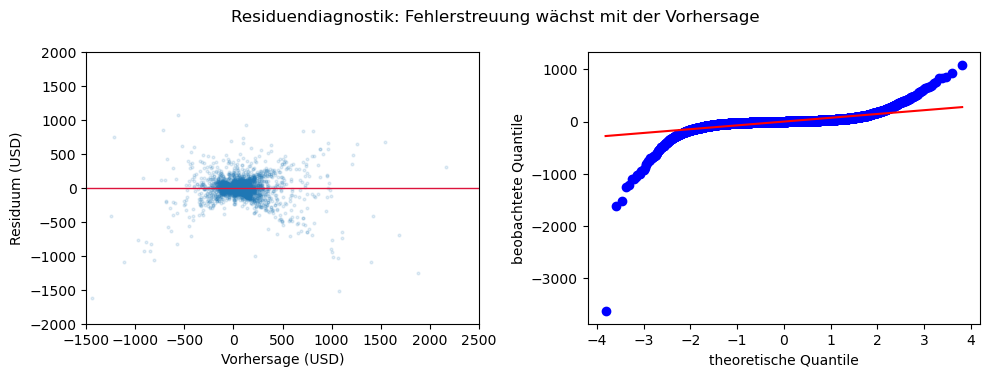

In [45]:
res = y_test - pred_lin
print("Korrelation |Residuum| mit Sales:", round(np.corrcoef(np.abs(res), test_df["Sales"])[0,1], 3))
print("Schiefe der Residuen:", round(float(stats.skew(res)), 2))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].scatter(pred_lin, res, s=4, alpha=0.12, color="#1f77b4"); ax[0].axhline(0, color="crimson", lw=1)
ax[0].set_xlim(-1500, 2500); ax[0].set_ylim(-2000, 2000)
ax[0].set_xlabel("Vorhersage (USD)"); ax[0].set_ylabel("Residuum (USD)")
stats.probplot(res, plot=ax[1]); ax[1].set_title("")
ax[1].set_xlabel("theoretische Quantile"); ax[1].set_ylabel("beobachtete Quantile")
fig.suptitle("Residuendiagnostik: Fehlerstreuung wächst mit der Vorhersage")
fig.tight_layout(); fig.savefig(f"{FIG}/abb4_residuen.png", dpi=150)
plt.show()


Nein. Die absolute Fehlergröße korreliert mit r = 0,74 mit dem Umsatz, die Fehlervarianz ist also stark heteroskedastisch. Das ist der typische Fingerabdruck eines multiplikativen Zusammenhangs, den man mit einem additiven Modell beschreibt. Genau deshalb der Wechsel der Zielgröße in Teil 07.

## Fehler nach Segmenten

Ein Modell, das im Betrieb laufen soll, muss nicht überall gleich gut sein. Man muss aber wissen, wo es schlechter ist.

In [46]:
seg = (test_df.assign(Fehler=np.abs(res))
       .groupby("Category")["Fehler"].agg(["mean", "median", "count"]).round(1)
       .rename(columns={"mean": "MAE", "median": "Median-Fehler", "count": "n"}))
seg.to_csv(f"{RES}/fehler_je_segment.csv")
seg

,MAE,Median-Fehler,n
Category,,,
Furniture,63.1,27.9,1960
Office Supplies,24.1,12.2,6235
Technology,71.3,32.1,2063


## Der vorgeschlagene Anwendungsfall

Der Bericht schlägt vor, Positionen mit hohem erwartetem Verlust bei der Auftragsannahme zu kennzeichnen. Das ist im Kern keine Regression, sondern eine Klassifikation. Hier prüfe ich, wie gut das Regressionsmodell diese Aufgabe erfüllt und ob es einfachere Alternativen gibt.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

ist_verlust = y_test < 0
kandidaten = {
    "Regression, linear (Notebook 06)": pred_lin < 0,
    "Regression, Random Forest":        pred_rf  < 0,
    "Fachregel: Discount > 0,2":        (test_df["Discount"] > 0.2).values,
}
clf = Pipeline([("prep", prep_C(2)), ("m", LogisticRegression(max_iter=2000))]).fit(X_train, y_train < 0)
kandidaten["Logistische Regression"] = clf.predict(X_test)

warn = pd.DataFrame([{"Verfahren": k,
                      "Precision": round(precision_score(ist_verlust, v), 3),
                      "Recall":    round(recall_score(ist_verlust, v), 3),
                      "F1":        round(f1_score(ist_verlust, v), 3)} for k, v in kandidaten.items()])
warn.to_csv(f"{RES}/warnsystem_vergleich.csv", index=False)
print("Anteil Verlustpositionen im Testset:", round(ist_verlust.mean(), 3))
warn

Anteil Verlustpositionen im Testset: 0.249


,Verfahren,Precision,Recall,F1
0,"Regression, linear (Notebook 06)",0.739,0.697,0.717
1,"Regression, Random Forest",0.914,0.784,0.844
2,"Fachregel: Discount > 0,2",0.898,0.806,0.849
3,Logistische Regression,0.894,0.805,0.848


Für diesen Zweck ist das Regressionsmodell aus Teil 06 die schlechteste der vier Optionen. Eine einzelne Fachregel (`Discount > 0,2`) erreicht das beste F1-Maß.

Konsequenz für den Bericht: Die Empfehlung stellt auf die Fachregel um. Die Regression bleibt dafür zuständig, die Höhe des erwarteten Gewinns zu schätzen, nicht für das Ja/Nein.

## Review

Die Zusatzanalysen bestätigen die vorsichtige Formulierung des Berichts. Sie zeigen aber auch, dass die ursprünglich vorgeschlagene Anwendung des Modells nicht die beste Lösung für ihr eigenes Ziel war. Alles eingearbeitet in Kapitel 3.5 und 4.